# EvolveGCN-H 750U Top1000 Mean vs Mean+Max Graph Pooling Results

This notebook analyzes a controlled graph-pooling ablation for EvolveGCN-H on the CAMELS-SIMBA `750U Top1000` no-normalization dataset.

The comparison is between:

1. the current best linear-head baseline with mean graph pooling, and
2. the same linear-head setup with mean+max graph pooling.

The goal is to test whether adding max-pooled graph information improves `Omega_m` prediction beyond the linear-head mean-pooling baseline. This notebook is analysis-only. It reads existing experiment results and writes derived tables and figures to `outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/`. It does not train models, modify experiment folders, modify processed data, alter source code, or change saved checkpoints.


## 1. Research Question

This controlled ablation addresses five questions:

1. Does `mean_max` pooling reduce MAE/RMSE?
2. Does it improve R²/Pearson?
3. Does it reduce residual bias?
4. Does it reduce or worsen prediction collapse?
5. Is mean pooling still likely to be the main bottleneck?


## 2. Controlled Setup

Only `graph_pooling` changes between the two groups. All other settings are held fixed.

| Field | Value |
|---|---|
| Dataset | 750U Top1000 none |
| Dataset path | `data/processed/temporal_750u_none_top1000_periodic_knn/camels_750u_temporal_logmass_none_top1000_periodic_knn.pt` |
| Model | EvolveGCN-H |
| Head | linear |
| Graph pooling compared | mean vs mean_max |
| Temporal pooling | mean |
| Seeds | 42, 123, 777, 999, 2025 |
| Hidden dim | 32 |
| Num layers | 2 |
| Dropout | 0.2 |
| Learning rate | 0.001 |
| Weight decay | 1e-05 |
| Changed variable | graph_pooling only |
| Baseline | linear head + mean graph pooling |
| New experiment | linear head + mean_max graph pooling |


## 3. Imports and Path Setup

The setup cell finds the repository root, creates the notebook-specific output folder, and configures compact display options for thesis-facing tables.


In [16]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False


def find_repo_root(start: Path | None = None) -> Path:
    """Find repository root from either the repo root or notebooks/visualization."""
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "experiments").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError("Could not find repository root containing experiments/ and notebooks/.")


REPO_ROOT = find_repo_root()
OUT_DIR = REPO_ROOT / "outputs" / "evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_PATH = REPO_ROOT / "data" / "processed" / "temporal_750u_none_top1000_periodic_knn" / "camels_750u_temporal_logmass_none_top1000_periodic_knn.pt"

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 190)

SAVED_CSVS: list[Path] = []
SAVED_PNGS: list[Path] = []

print(f"Repository root: {REPO_ROOT}")
print(f"Output folder:   {OUT_DIR}")
print(f"Dataset path:    {DATASET_PATH}")
print(f"sklearn available: {SKLEARN_AVAILABLE}")


Repository root: <REPO_ROOT>
Output folder:   <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results
Dataset path:    <REPO_ROOT>/data/processed/temporal_750u_none_top1000_periodic_knn/camels_750u_temporal_logmass_none_top1000_periodic_knn.pt
sklearn available: True


## 4. Helper Functions

The helper functions below load `config.json`, `metrics.json`, and `predictions/test_predictions.csv`, infer prediction columns, compute regression and collapse metrics, and save tables/figures in a consistent thesis-facing style.


In [17]:
def load_json_safe(path: Path) -> dict:
    if not path.exists():
        warnings.warn(f"Missing JSON file: {path}")
        return {}
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def load_prediction_csv(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        warnings.warn(f"Missing prediction CSV: {path}")
        return None
    return pd.read_csv(path)


def infer_true_pred_columns(df: pd.DataFrame) -> tuple[str, str]:
    true_candidates = ["true_omega_m", "target", "y_true", "true", "omega_m", "Omega_m", "actual"]
    pred_candidates = ["pred_omega_m", "prediction", "pred", "y_pred", "predicted", "output"]
    true_col = next((col for col in true_candidates if col in df.columns), None)
    pred_col = next((col for col in pred_candidates if col in df.columns), None)
    if true_col is None or pred_col is None:
        raise KeyError(f"Could not infer target/prediction columns from: {list(df.columns)}")
    return true_col, pred_col


def compute_mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    if SKLEARN_AVAILABLE:
        return float(mean_absolute_error(y_true, y_pred))
    return float(np.mean(np.abs(y_true - y_pred)))


def compute_rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    if SKLEARN_AVAILABLE:
        return float(mean_squared_error(y_true, y_pred) ** 0.5)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def compute_r2(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    if SKLEARN_AVAILABLE:
        return float(r2_score(y_true, y_pred))
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    return float("nan") if ss_tot == 0.0 else 1.0 - ss_res / ss_tot


def compute_pearson(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    if len(y_true) < 2 or np.std(y_true) < 1e-12 or np.std(y_pred) < 1e-12:
        return float("nan")
    return float(np.corrcoef(y_true, y_pred)[0, 1])


def compute_std_ratio(y_true: np.ndarray, y_pred: np.ndarray) -> tuple[float, float, float]:
    target_std = float(np.std(y_true))
    pred_std = float(np.std(y_pred))
    ratio = pred_std / target_std if target_std > 1e-12 else float("nan")
    return target_std, pred_std, float(ratio)


def repeated_prediction_stats(y_pred: np.ndarray, decimals: int = 6) -> dict:
    rounded = np.round(y_pred.astype(float), decimals=decimals)
    values, counts = np.unique(rounded, return_counts=True)
    top_index = int(np.argmax(counts))
    repeat_count = int(counts[top_index])
    return {
        "most_repeated_prediction": float(values[top_index]),
        "repeat_count": repeat_count,
        "repeat_fraction": float(repeat_count / len(y_pred)) if len(y_pred) else float("nan"),
        "unique_rounded_predictions": int(len(values)),
    }


def format_mean_std(mean_value: float, std_value: float, decimals: int = 4) -> str:
    if pd.isna(mean_value):
        return "n/a"
    if pd.isna(std_value):
        return f"{mean_value:.{decimals}f} ± n/a"
    return f"{mean_value:.{decimals}f} ± {std_value:.{decimals}f}"


def save_csv(df: pd.DataFrame, path: Path) -> None:
    df.to_csv(path, index=False)
    SAVED_CSVS.append(path)
    print(f"Saved: {path}")


def save_current_figure(path: Path) -> None:
    plt.savefig(path, dpi=200, bbox_inches="tight")
    SAVED_PNGS.append(path)
    print(f"Saved: {path}")


def save_table_png(df: pd.DataFrame, path: Path, title: str | None = None, max_rows: int | None = None) -> None:
    shown = df.copy()
    if max_rows is not None:
        shown = shown.head(max_rows)
    fig_height = max(2.2, 0.36 * len(shown) + (0.7 if title else 0.2))
    fig_width = max(9.0, min(24.0, 1.35 * len(shown.columns)))
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=12, pad=12)
    table = ax.table(cellText=shown.astype(str).values, colLabels=shown.columns, cellLoc="center", colLoc="center", loc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(7.5)
    table.scale(1.0, 1.35)
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#eeeeee")
    fig.tight_layout()
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    SAVED_PNGS.append(path)
    print(f"Saved: {path}")


def yes_no(condition: bool) -> str:
    return "Yes" if bool(condition) else "No"


## 5. Experiment Registry

The registry lists the ten completed experiments in the controlled 5-seed graph-pooling comparison.


In [18]:
SEEDS = [42, 123, 777, 999, 2025]

EXPERIMENTS = []
for seed in SEEDS:
    EXPERIMENTS.append({
        "Pooling": "Mean",
        "Seed": seed,
        "Experiment": f"evolvegcn_h_750u_top1000_h32_seed{seed}_none_linear_head",
        "Experiment Path": REPO_ROOT / "experiments" / f"evolvegcn_h_750u_top1000_h32_seed{seed}_none_linear_head",
    })
    EXPERIMENTS.append({
        "Pooling": "MeanMax",
        "Seed": seed,
        "Experiment": f"evolvegcn_h_750u_top1000_h32_seed{seed}_none_linear_head_meanmax",
        "Experiment Path": REPO_ROOT / "experiments" / f"evolvegcn_h_750u_top1000_h32_seed{seed}_none_linear_head_meanmax",
    })

registry_df = pd.DataFrame(EXPERIMENTS)
display(registry_df[["Pooling", "Seed", "Experiment", "Experiment Path"]])


,Pooling,Seed,Experiment,Experiment Path
0,Mean,42,evolvegcn_h_750u_top1000_h32_seed42_none_linea...,/experiments/evolvegcn_h...
1,MeanMax,42,evolvegcn_h_750u_top1000_h32_seed42_none_linea...,/experiments/evolvegcn_h...
2,Mean,123,evolvegcn_h_750u_top1000_h32_seed123_none_line...,/experiments/evolvegcn_h...
3,MeanMax,123,evolvegcn_h_750u_top1000_h32_seed123_none_line...,/experiments/evolvegcn_h...
4,Mean,777,evolvegcn_h_750u_top1000_h32_seed777_none_line...,/experiments/evolvegcn_h...
5,MeanMax,777,evolvegcn_h_750u_top1000_h32_seed777_none_line...,/experiments/evolvegcn_h...
6,Mean,999,evolvegcn_h_750u_top1000_h32_seed999_none_line...,/experiments/evolvegcn_h...
7,MeanMax,999,evolvegcn_h_750u_top1000_h32_seed999_none_line...,/experiments/evolvegcn_h...
8,Mean,2025,evolvegcn_h_750u_top1000_h32_seed2025_none_lin...,/experiments/evolvegcn_h...
9,MeanMax,2025,evolvegcn_h_750u_top1000_h32_seed2025_none_lin...,/experiments/evolvegcn_h...


## 6. Seed-Level Results

This section reads only `config.json`, `metrics.json`, and `predictions/test_predictions.csv` from each experiment. Metrics are recomputed from the test prediction CSVs so that MAE, RMSE, R², Pearson correlation, prediction spread, and repeated-prediction diagnostics are comparable across runs.


In [19]:
rows = []
warning_rows = []
predictions_by_experiment: dict[str, pd.DataFrame] = {}

for item in EXPERIMENTS:
    exp_dir = Path(item["Experiment Path"])
    config_path = exp_dir / "config.json"
    metrics_path = exp_dir / "metrics.json"
    prediction_path = exp_dir / "predictions" / "test_predictions.csv"

    missing = []
    if not exp_dir.exists(): missing.append("experiment_dir")
    if not config_path.exists(): missing.append("config.json")
    if not metrics_path.exists(): missing.append("metrics.json")
    if not prediction_path.exists(): missing.append("predictions/test_predictions.csv")

    if missing:
        warning_rows.append({**item, "Missing": ", ".join(missing)})
        continue

    config = load_json_safe(config_path)
    metrics = load_json_safe(metrics_path)
    pred_df = load_prediction_csv(prediction_path)
    if pred_df is None:
        warning_rows.append({**item, "Missing": "predictions/test_predictions.csv"})
        continue

    true_col, pred_col = infer_true_pred_columns(pred_df)
    y_true = pred_df[true_col].to_numpy(dtype=float)
    y_pred = pred_df[pred_col].to_numpy(dtype=float)
    target_std, pred_std, std_ratio = compute_std_ratio(y_true, y_pred)
    repeat_stats = repeated_prediction_stats(y_pred, decimals=6)
    test_metrics = metrics.get("test", {}) if isinstance(metrics, dict) else {}

    rows.append({
        "Pooling": item["Pooling"],
        "Seed": item["Seed"],
        "Experiment": item["Experiment"],
        "Dataset Path": config.get("dataset_path"),
        "Graph Pooling": config.get("graph_pooling"),
        "Temporal Pooling": config.get("temporal_pooling"),
        "Hidden Dim": config.get("hidden_dim"),
        "Num Layers": config.get("num_layers"),
        "Dropout": config.get("dropout"),
        "Learning Rate": config.get("learning_rate"),
        "Weight Decay": config.get("weight_decay"),
        "Test MAE": compute_mae(y_true, y_pred),
        "Test RMSE": compute_rmse(y_true, y_pred),
        "Test R²": compute_r2(y_true, y_pred),
        "Pearson": compute_pearson(y_true, y_pred),
        "Target Std": target_std,
        "Prediction Std": pred_std,
        "Prediction Std / Target Std": std_ratio,
        "Most Repeated Prediction": repeat_stats["most_repeated_prediction"],
        "Repeat Count": repeat_stats["repeat_count"],
        "Repeat Fraction": repeat_stats["repeat_fraction"],
        "Unique Rounded Predictions": repeat_stats["unique_rounded_predictions"],
        "N Test Samples": len(pred_df),
        "Metrics JSON Test MAE": test_metrics.get("mae"),
        "Metrics JSON Test RMSE": test_metrics.get("rmse"),
    })

    pred_copy = pred_df.copy()
    pred_copy["Pooling"] = item["Pooling"]
    pred_copy["Seed"] = item["Seed"]
    pred_copy["Experiment"] = item["Experiment"]
    pred_copy["true"] = y_true
    pred_copy["pred"] = y_pred
    pred_copy["residual"] = y_pred - y_true
    predictions_by_experiment[item["Experiment"]] = pred_copy

seed_results_df = pd.DataFrame(rows).sort_values(["Pooling", "Seed"]).reset_index(drop=True)
warning_df = pd.DataFrame(warning_rows)

ordered_seed_cols = [
    "Pooling", "Seed", "Experiment", "Test MAE", "Test RMSE", "Test R²", "Pearson",
    "Target Std", "Prediction Std", "Prediction Std / Target Std", "Most Repeated Prediction",
    "Repeat Count", "Repeat Fraction", "Unique Rounded Predictions", "N Test Samples",
]
seed_results_export = seed_results_df[ordered_seed_cols].copy()
save_csv(seed_results_export, OUT_DIR / "seed_level_results.csv")

if not warning_df.empty:
    save_csv(warning_df, OUT_DIR / "missing_experiment_warnings.csv")
    display(warning_df)
else:
    print("No missing experiment files detected.")

seed_display_df = seed_results_export.copy()
for col in ["Test MAE", "Test RMSE", "Test R²", "Pearson", "Target Std", "Prediction Std", "Prediction Std / Target Std", "Repeat Fraction"]:
    seed_display_df[col] = seed_display_df[col].map(lambda x: f"{x:.6f}")
seed_display_df["Most Repeated Prediction"] = seed_display_df["Most Repeated Prediction"].map(lambda x: f"{x:.6f}")

display(seed_display_df)
save_table_png(seed_display_df, OUT_DIR / "seed_level_results_table.png", title="Seed-Level Mean vs Mean+Max Pooling Results")


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/seed_level_results.csv
No missing experiment files detected.


,Pooling,Seed,Experiment,Test MAE,Test RMSE,Test R²,Pearson,Target Std,Prediction Std,Prediction Std / Target Std,Most Repeated Prediction,Repeat Count,Repeat Fraction,Unique Rounded Predictions,N Test Samples
0,Mean,42,evolvegcn_h_750u_top1000_h32_seed42_none_linea...,0.050295,0.061928,0.738381,0.877929,0.121074,0.090606,0.748353,0.078997,1,0.004975,201,201
1,Mean,123,evolvegcn_h_750u_top1000_h32_seed123_none_line...,0.052324,0.066923,0.656075,0.843979,0.114115,0.111763,0.979391,0.057471,1,0.004975,201,201
2,Mean,777,evolvegcn_h_750u_top1000_h32_seed777_none_line...,0.067711,0.084683,0.475684,0.729585,0.116949,0.087950,0.752037,0.030117,1,0.004975,201,201
3,Mean,999,evolvegcn_h_750u_top1000_h32_seed999_none_line...,0.046755,0.064049,0.689230,0.853181,0.114893,0.118889,1.034781,-0.021409,1,0.004975,201,201
4,Mean,2025,evolvegcn_h_750u_top1000_h32_seed2025_none_lin...,0.062131,0.078096,0.579114,0.766375,0.120378,0.096028,0.797722,0.029120,1,0.004975,201,201
5,MeanMax,42,evolvegcn_h_750u_top1000_h32_seed42_none_linea...,0.091449,0.112490,0.136760,0.639628,0.121074,0.089468,0.738956,0.059043,1,0.004975,201,201
6,MeanMax,123,evolvegcn_h_750u_top1000_h32_seed123_none_line...,0.075374,0.116001,-0.033333,0.462186,0.114115,0.108584,0.951536,-0.539195,1,0.004975,201,201
7,MeanMax,777,evolvegcn_h_750u_top1000_h32_seed777_none_line...,0.092554,0.122616,-0.099262,0.636578,0.116949,0.145912,1.247653,0.049389,1,0.004975,201,201
8,MeanMax,999,evolvegcn_h_750u_top1000_h32_seed999_none_line...,0.073649,0.093887,0.332226,0.682736,0.114893,0.091584,0.797127,0.054036,1,0.004975,201,201
9,MeanMax,2025,evolvegcn_h_750u_top1000_h32_seed2025_none_lin...,0.071840,0.085853,0.491350,0.715613,0.120378,0.070074,0.582120,0.079299,1,0.004975,201,201


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/seed_level_results_table.png


## 7. Mean ± Std Summary

This section aggregates the five seeds for each graph-pooling setting. The numeric CSV preserves exact mean and standard deviation values, while the mean ± std table is formatted for thesis slides and meeting notes.


In [20]:
SUMMARY_METRICS = ["Test MAE", "Test RMSE", "Test R²", "Pearson", "Prediction Std / Target Std", "Repeat Fraction"]

group_summary_numeric = seed_results_df.groupby("Pooling", sort=False)[SUMMARY_METRICS].agg(["mean", "std", "count"]).reset_index()
group_summary_numeric.columns = ["_".join(col).rstrip("_") if isinstance(col, tuple) else col for col in group_summary_numeric.columns]

mean_std_rows = []
for _, row in group_summary_numeric.iterrows():
    output_row = {"Pooling": row["Pooling"]}
    for metric in SUMMARY_METRICS:
        output_row[metric] = format_mean_std(row[f"{metric}_mean"], row[f"{metric}_std"], decimals=4)
    mean_std_rows.append(output_row)

group_summary_mean_std = pd.DataFrame(mean_std_rows)

save_csv(group_summary_numeric, OUT_DIR / "group_summary_numeric.csv")
save_csv(group_summary_mean_std, OUT_DIR / "group_summary_mean_std.csv")

display(group_summary_mean_std)
save_table_png(group_summary_mean_std, OUT_DIR / "group_summary_mean_std_table.png", title="Mean vs Mean+Max Pooling Mean ± Std Summary")


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/group_summary_numeric.csv
Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/group_summary_mean_std.csv


,Pooling,Test MAE,Test RMSE,Test R²,Pearson,Prediction Std / Target Std,Repeat Fraction
0,Mean,0.0558 ± 0.0087,0.0711 ± 0.0098,0.6277 ± 0.1028,0.8142 ± 0.0631,0.8625 ± 0.1349,0.0050 ± 0.0000
1,MeanMax,0.0810 ± 0.0102,0.1062 ± 0.0156,0.1655 ± 0.2472,0.6273 ± 0.0979,0.8635 ± 0.2522,0.0050 ± 0.0000


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/group_summary_mean_std_table.png


## 8. Main Result Rule

Mean+max pooling should only be considered successful if it improves mean MAE below the mean-pooling baseline and improves at least 3/5 matched seeds. Because the seeds are shared, the paired seed comparison is the most direct test of whether the graph-pooling change helps consistently rather than only shifting one outlier run.


In [21]:
summary_lookup = group_summary_numeric.set_index("Pooling")
mean_summary = summary_lookup.loc["Mean"]
meanmax_summary = summary_lookup.loc["MeanMax"]

main_result_text = f"""
Mean-pooling mean MAE: `{mean_summary['Test MAE_mean']:.6f} ± {mean_summary['Test MAE_std']:.6f}`.  
Mean+max-pooling mean MAE: `{meanmax_summary['Test MAE_mean']:.6f} ± {meanmax_summary['Test MAE_std']:.6f}`.

The success rule will be evaluated below using both the mean MAE comparison and the matched seed-level MAE deltas.
"""
display(Markdown(main_result_text))



Mean-pooling mean MAE: `0.055843 ± 0.008748`.  
Mean+max-pooling mean MAE: `0.080973 ± 0.010152`.

The success rule will be evaluated below using both the mean MAE comparison and the matched seed-level MAE deltas.


## 9. Metric Comparison Plots

The following plots compare group-level mean performance with one-standard-deviation error bars across seeds. Lower MAE, RMSE, and repeat fraction are better; higher R² and Pearson correlation are better. For prediction spread, a prediction-standard-deviation ratio closer to 1 indicates prediction spread closer to the target spread.


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/mae_comparison_mean_std.png


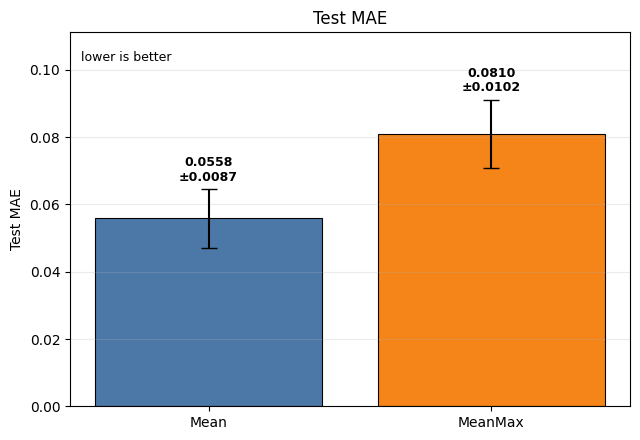

Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/rmse_comparison_mean_std.png


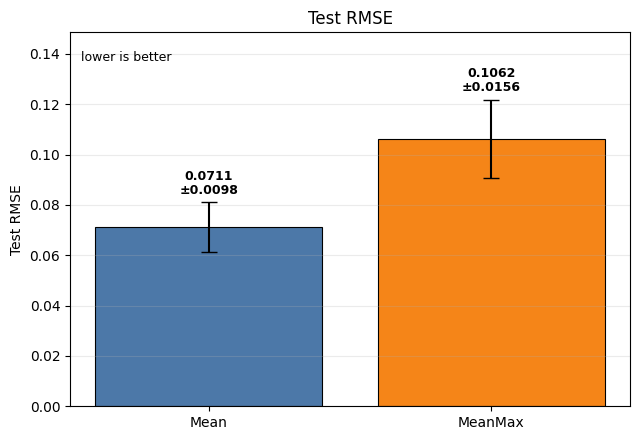

Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/r2_comparison_mean_std.png


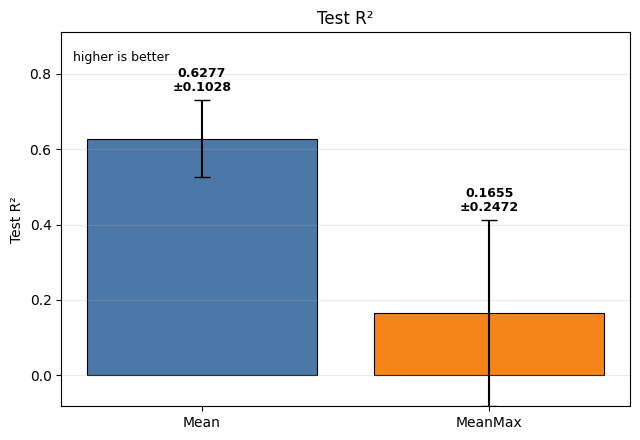

Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/pearson_comparison_mean_std.png


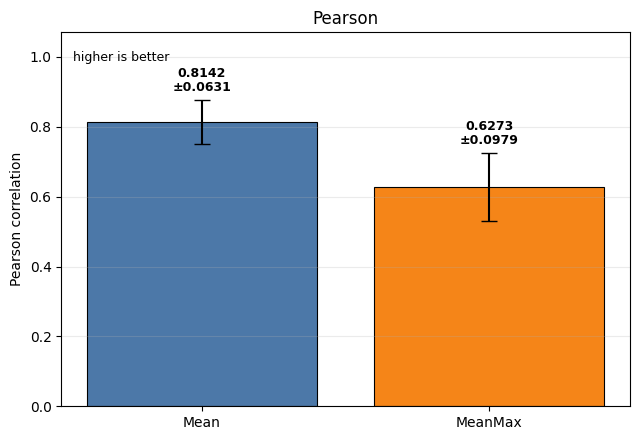

Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/pred_std_ratio_comparison_mean_std.png


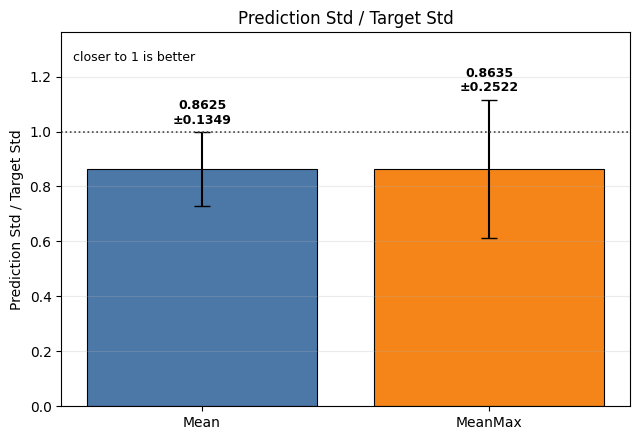

Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/repeat_fraction_comparison_mean_std.png


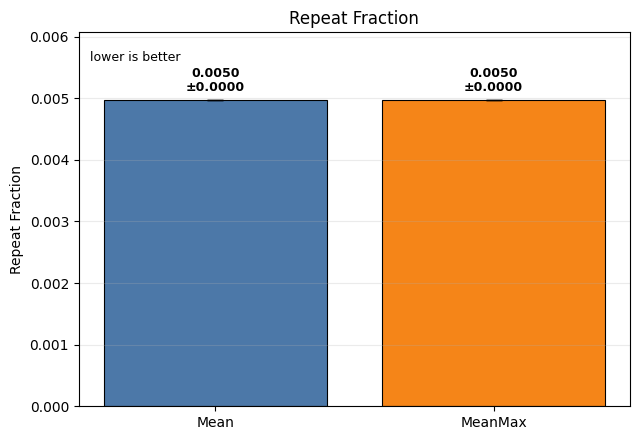

In [22]:
def plot_group_metric(metric: str, filename: str, ylabel: str | None = None, higher_is_better: bool | None = None) -> None:
    mean_col = f"{metric}_mean"
    std_col = f"{metric}_std"
    plot_df = group_summary_numeric.copy()
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    bars = ax.bar(
        plot_df["Pooling"],
        plot_df[mean_col],
        yerr=plot_df[std_col],
        capsize=6,
        color=["#4c78a8", "#f58518"],
        edgecolor="black",
        linewidth=0.8,
    )
    ax.set_title(metric)
    ax.set_ylabel(ylabel or metric)
    ax.grid(axis="y", alpha=0.25)

    means = plot_df[mean_col].astype(float).to_numpy()
    stds = plot_df[std_col].astype(float).fillna(0.0).to_numpy()
    y_min = min(0.0, float(np.nanmin(means - stds)))
    y_max = float(np.nanmax(means + stds))
    pad = (y_max - y_min) * 0.22 if y_max > y_min else max(abs(y_max) * 0.22, 0.05)
    ax.set_ylim(y_min, y_max + pad)

    for bar, mean_value, std_value in zip(bars, means, stds):
        label_y = mean_value + std_value + pad * 0.08
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            label_y,
            f"{mean_value:.4f}\n±{std_value:.4f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            linespacing=1.15,
        )

    if higher_is_better is True:
        ax.text(0.02, 0.95, "higher is better", transform=ax.transAxes, va="top", fontsize=9)
    elif higher_is_better is False:
        ax.text(0.02, 0.95, "lower is better", transform=ax.transAxes, va="top", fontsize=9)
    else:
        ax.text(0.02, 0.95, "closer to 1 is better", transform=ax.transAxes, va="top", fontsize=9)
        ax.axhline(1.0, color="#444444", linestyle=":", linewidth=1.2)
    fig.tight_layout()
    save_current_figure(OUT_DIR / filename)
    plt.show()

plot_group_metric("Test MAE", "mae_comparison_mean_std.png", ylabel="Test MAE", higher_is_better=False)
plot_group_metric("Test RMSE", "rmse_comparison_mean_std.png", ylabel="Test RMSE", higher_is_better=False)
plot_group_metric("Test R²", "r2_comparison_mean_std.png", ylabel="Test R²", higher_is_better=True)
plot_group_metric("Pearson", "pearson_comparison_mean_std.png", ylabel="Pearson correlation", higher_is_better=True)
plot_group_metric("Prediction Std / Target Std", "pred_std_ratio_comparison_mean_std.png", ylabel="Prediction Std / Target Std", higher_is_better=None)
plot_group_metric("Repeat Fraction", "repeat_fraction_comparison_mean_std.png", ylabel="Repeat Fraction", higher_is_better=False)


## 10. Paired Seed Comparison

Because both settings use the same seeds, this paired table compares matched splits directly. A negative delta means `MeanMax` had lower MAE than `Mean` for that seed.


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/paired_seed_mae_comparison.csv


,Seed,Mean MAE,MeanMax MAE,Delta MAE = MeanMax - Mean,Improved?
0,42,0.050295,0.091449,0.041155,False
1,123,0.052324,0.075374,0.023050,False
2,777,0.067711,0.092554,0.024843,False
3,999,0.046755,0.073649,0.026894,False
4,2025,0.062131,0.071840,0.009709,False


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/paired_seed_mae_comparison.png


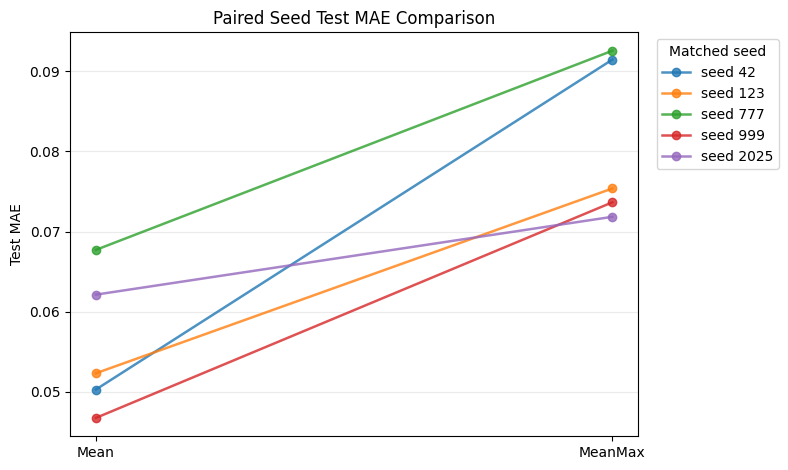

In [23]:
mean_seed = seed_results_df[seed_results_df["Pooling"] == "Mean"][["Seed", "Test MAE"]].rename(columns={"Test MAE": "Mean MAE"})
meanmax_seed = seed_results_df[seed_results_df["Pooling"] == "MeanMax"][["Seed", "Test MAE"]].rename(columns={"Test MAE": "MeanMax MAE"})
paired_seed_mae = mean_seed.merge(meanmax_seed, on="Seed", how="outer").sort_values("Seed").reset_index(drop=True)
paired_seed_mae["Delta MAE = MeanMax - Mean"] = paired_seed_mae["MeanMax MAE"] - paired_seed_mae["Mean MAE"]
paired_seed_mae["Improved?"] = paired_seed_mae["Delta MAE = MeanMax - Mean"] < 0

save_csv(paired_seed_mae, OUT_DIR / "paired_seed_mae_comparison.csv")
display(paired_seed_mae)

fig, ax = plt.subplots(figsize=(8, 4.8))
for _, row in paired_seed_mae.iterrows():
    ax.plot(["Mean", "MeanMax"], [row["Mean MAE"], row["MeanMax MAE"]], marker="o", linewidth=1.8, alpha=0.8, label=f"seed {int(row['Seed'])}")
ax.set_title("Paired Seed Test MAE Comparison")
ax.set_ylabel("Test MAE")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Matched seed", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
save_current_figure(OUT_DIR / "paired_seed_mae_comparison.png")
plt.show()


## 11. Prediction Diagnostics

The following diagnostics combine all available test predictions across seeds for each graph-pooling setting. The true-vs-predicted plots include a 1:1 line, residual plots include a zero line, and paired plot types share axis limits where appropriate.


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/true_vs_predicted_mean_all_seeds.png


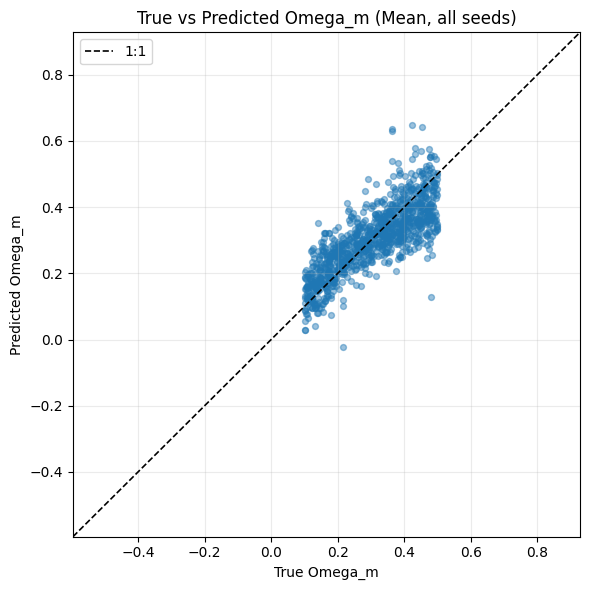

Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/true_vs_predicted_meanmax_all_seeds.png


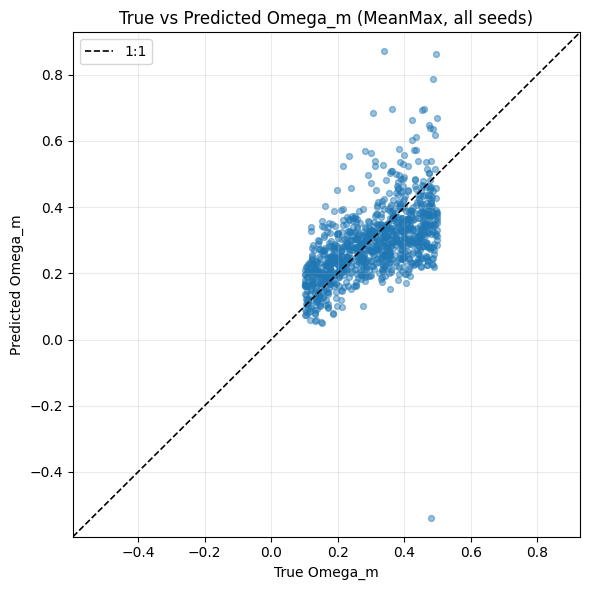

Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/residuals_vs_true_mean_all_seeds.png


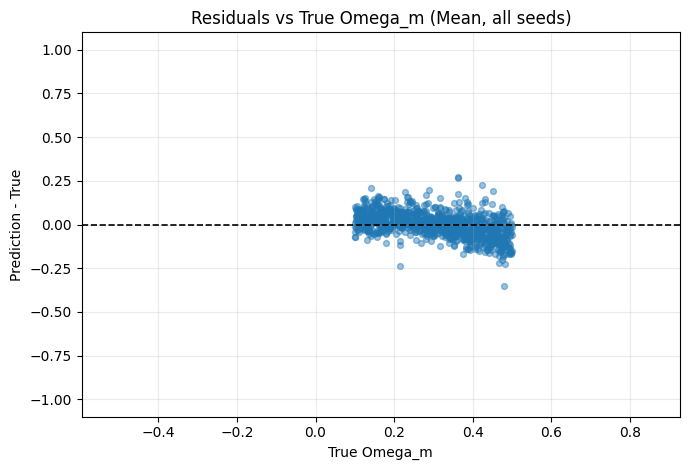

Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/residuals_vs_true_meanmax_all_seeds.png


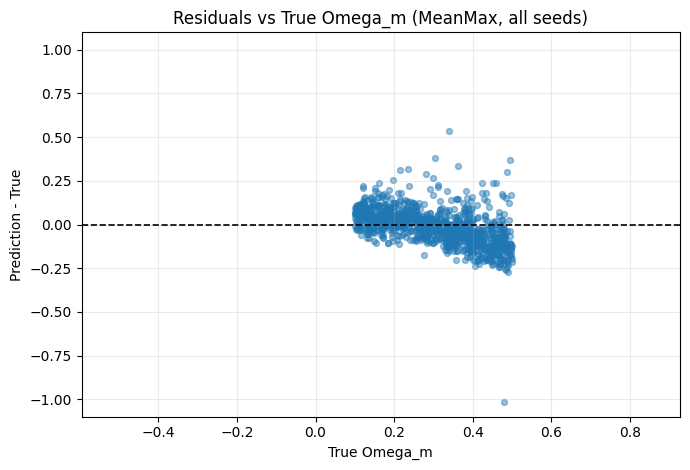

Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/prediction_distribution_mean_vs_meanmax.png


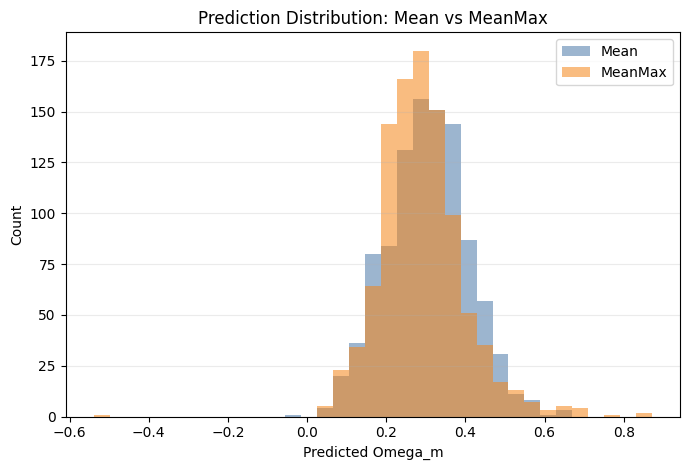

In [24]:
def combined_predictions(pooling: str) -> pd.DataFrame:
    frames = [df for df in predictions_by_experiment.values() if df["Pooling"].iloc[0] == pooling]
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def global_true_pred_limits() -> tuple[float, float]:
    frames = [combined_predictions("Mean"), combined_predictions("MeanMax")]
    values = []
    for frame in frames:
        if not frame.empty:
            values.extend(frame["true"].to_numpy(dtype=float))
            values.extend(frame["pred"].to_numpy(dtype=float))
    lo = float(np.nanmin(values))
    hi = float(np.nanmax(values))
    pad = (hi - lo) * 0.04 if hi > lo else 0.01
    return lo - pad, hi + pad


def global_residual_limits() -> tuple[float, float]:
    frames = [combined_predictions("Mean"), combined_predictions("MeanMax")]
    residuals = np.concatenate([frame["residual"].to_numpy(dtype=float) for frame in frames if not frame.empty])
    max_abs = float(np.nanmax(np.abs(residuals))) if len(residuals) else 0.1
    return -max_abs * 1.08, max_abs * 1.08


def plot_true_vs_pred(pooling: str, filename: str) -> None:
    df = combined_predictions(pooling)
    lo, hi = global_true_pred_limits()
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(df["true"], df["pred"], alpha=0.45, s=18)
    ax.plot([lo, hi], [lo, hi], color="black", linestyle="--", linewidth=1.2, label="1:1")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_title(f"True vs Predicted Omega_m ({pooling}, all seeds)")
    ax.set_xlabel("True Omega_m")
    ax.set_ylabel("Predicted Omega_m")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    save_current_figure(OUT_DIR / filename)
    plt.show()


def plot_residuals(pooling: str, filename: str) -> None:
    df = combined_predictions(pooling)
    lo, hi = global_true_pred_limits()
    rlo, rhi = global_residual_limits()
    fig, ax = plt.subplots(figsize=(7, 4.8))
    ax.scatter(df["true"], df["residual"], alpha=0.45, s=18)
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1.2)
    ax.set_xlim(lo, hi)
    ax.set_ylim(rlo, rhi)
    ax.set_title(f"Residuals vs True Omega_m ({pooling}, all seeds)")
    ax.set_xlabel("True Omega_m")
    ax.set_ylabel("Prediction - True")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    save_current_figure(OUT_DIR / filename)
    plt.show()

plot_true_vs_pred("Mean", "true_vs_predicted_mean_all_seeds.png")
plot_true_vs_pred("MeanMax", "true_vs_predicted_meanmax_all_seeds.png")
plot_residuals("Mean", "residuals_vs_true_mean_all_seeds.png")
plot_residuals("MeanMax", "residuals_vs_true_meanmax_all_seeds.png")

mean_df = combined_predictions("Mean")
meanmax_df = combined_predictions("MeanMax")
fig, ax = plt.subplots(figsize=(7, 4.8))
bins = np.linspace(min(mean_df["pred"].min(), meanmax_df["pred"].min()), max(mean_df["pred"].max(), meanmax_df["pred"].max()), 36)
ax.hist(mean_df["pred"], bins=bins, alpha=0.55, label="Mean", color="#4c78a8")
ax.hist(meanmax_df["pred"], bins=bins, alpha=0.55, label="MeanMax", color="#f58518")
ax.set_title("Prediction Distribution: Mean vs MeanMax")
ax.set_xlabel("Predicted Omega_m")
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.tight_layout()
save_current_figure(OUT_DIR / "prediction_distribution_mean_vs_meanmax.png")
plt.show()


**Note on visual scale:** the Mean-pooling scatter in this notebook uses axis limits shared with the MeanMax comparison. Because MeanMax produced several extreme predictions, the shared axis range is wider than in Notebook 08. The underlying Mean-pooling predictions are identical to the Linear-head Mean-pooling baseline shown in Notebook 08; only the plot scaling differs.


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/true_vs_predicted_mean_vs_meanmax_zoomed_baseline_range.png


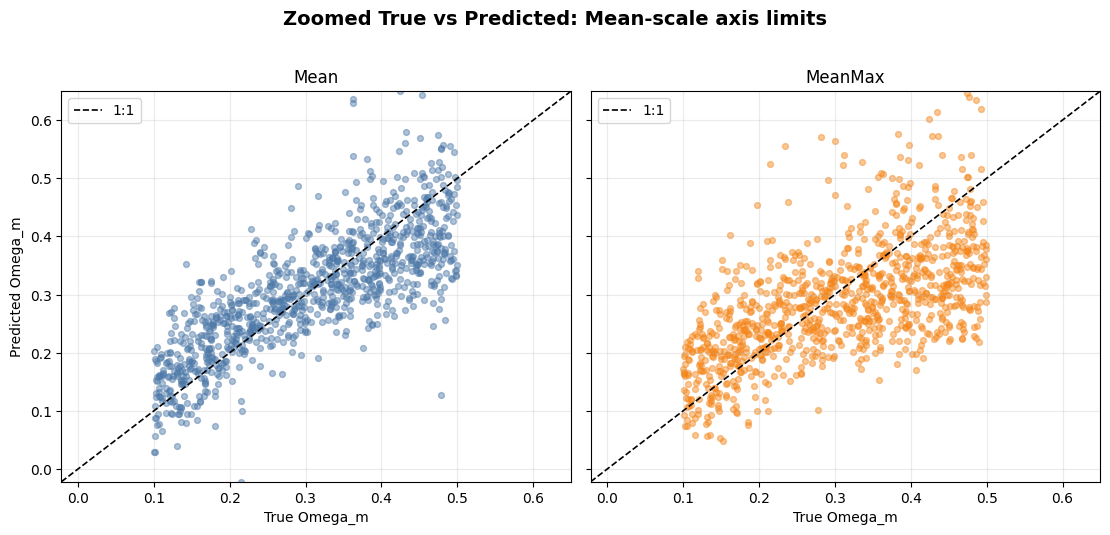

In [25]:
mean_df = combined_predictions("Mean")
meanmax_df = combined_predictions("MeanMax")

lo = float(min(mean_df["true"].min(), mean_df["pred"].min()))
hi = float(max(mean_df["true"].max(), mean_df["pred"].max()))

fig, axes = plt.subplots(1, 2, figsize=(11.2, 5.2), sharex=True, sharey=True)
plot_specs = [
    ("Mean", mean_df, "#4c78a8"),
    ("MeanMax", meanmax_df, "#f58518"),
]

for ax, (label, df, color) in zip(axes, plot_specs):
    ax.scatter(df["true"], df["pred"], alpha=0.45, s=18, color=color)
    ax.plot([lo, hi], [lo, hi], color="black", linestyle="--", linewidth=1.2, label="1:1")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_title(label)
    ax.set_xlabel("True Omega_m")
    ax.grid(alpha=0.25)
    ax.legend()

axes[0].set_ylabel("Predicted Omega_m")
fig.suptitle("Zoomed True vs Predicted: Mean-scale axis limits", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
save_current_figure(OUT_DIR / "true_vs_predicted_mean_vs_meanmax_zoomed_baseline_range.png")
plt.show()


This zoomed view makes the baseline visually comparable to Notebook 08 while still showing that MeanMax has more out-of-range/extreme predictions.


## 12. Collapse Diagnostics

A good model should not rely on repeated identical predictions and should have prediction spread closer to target spread. Values of `Prediction Std / Target Std` far below 1 indicate that predictions vary less than the true targets.


In [26]:
collapse_table = seed_results_df[["Pooling", "Seed", "Prediction Std / Target Std", "Repeat Count", "Repeat Fraction", "Most Repeated Prediction"]].copy()
collapse_display = collapse_table.copy()
for col in ["Prediction Std / Target Std", "Repeat Fraction", "Most Repeated Prediction"]:
    collapse_display[col] = collapse_display[col].map(lambda x: f"{x:.6f}")

display(collapse_display)
save_csv(collapse_table, OUT_DIR / "collapse_diagnostics_seed_level.csv")
save_table_png(collapse_display, OUT_DIR / "collapse_diagnostics_seed_level_table.png", title="Prediction-Collapse and Repeated-Prediction Diagnostics")


,Pooling,Seed,Prediction Std / Target Std,Repeat Count,Repeat Fraction,Most Repeated Prediction
0,Mean,42,0.748353,1,0.004975,0.078997
1,Mean,123,0.979391,1,0.004975,0.057471
2,Mean,777,0.752037,1,0.004975,0.030117
3,Mean,999,1.034781,1,0.004975,-0.021409
4,Mean,2025,0.797722,1,0.004975,0.029120
5,MeanMax,42,0.738956,1,0.004975,0.059043
6,MeanMax,123,0.951536,1,0.004975,-0.539195
7,MeanMax,777,1.247653,1,0.004975,0.049389
8,MeanMax,999,0.797127,1,0.004975,0.054036
9,MeanMax,2025,0.582120,1,0.004975,0.079299


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/collapse_diagnostics_seed_level.csv
Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/collapse_diagnostics_seed_level_table.png


## 13. Best-Seed Sorted Curve

This plot compares the best mean-pooling seed and the best mean+max-pooling seed by Test MAE. The test samples are sorted by true `Omega_m` so prediction compression and residual structure are easier to see.


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/sorted_true_vs_predicted_best_mean_vs_best_meanmax.png


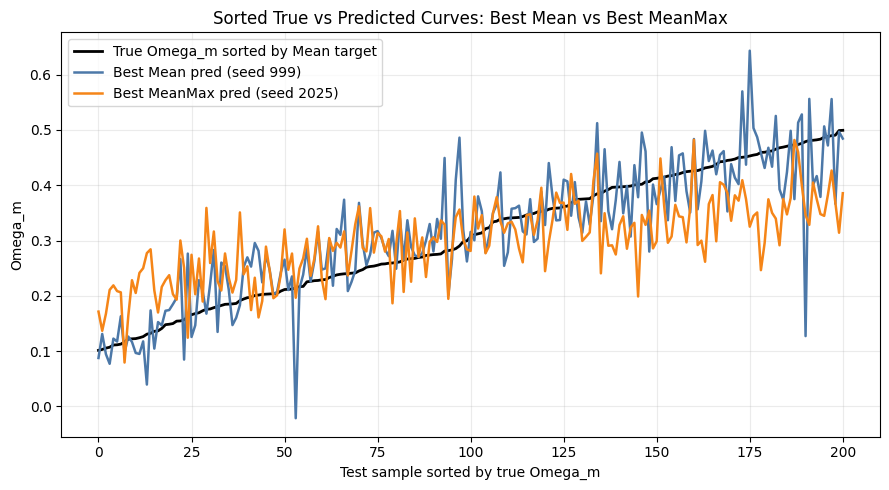

Best Mean seed: 999, Test MAE=0.046755
Best MeanMax seed: 2025, Test MAE=0.071840


In [27]:
best_mean_row = seed_results_df[seed_results_df["Pooling"] == "Mean"].sort_values("Test MAE").iloc[0]
best_meanmax_row = seed_results_df[seed_results_df["Pooling"] == "MeanMax"].sort_values("Test MAE").iloc[0]

best_mean_df = predictions_by_experiment[best_mean_row["Experiment"]].sort_values("true").reset_index(drop=True)
best_meanmax_df = predictions_by_experiment[best_meanmax_row["Experiment"]].sort_values("true").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(best_mean_df.index, best_mean_df["true"], color="black", linewidth=2.0, label="True Omega_m sorted by Mean target")
ax.plot(best_mean_df.index, best_mean_df["pred"], color="#4c78a8", linewidth=1.8, label=f"Best Mean pred (seed {int(best_mean_row['Seed'])})")
ax.plot(best_meanmax_df.index, best_meanmax_df["pred"], color="#f58518", linewidth=1.8, label=f"Best MeanMax pred (seed {int(best_meanmax_row['Seed'])})")
ax.set_title("Sorted True vs Predicted Curves: Best Mean vs Best MeanMax")
ax.set_xlabel("Test sample sorted by true Omega_m")
ax.set_ylabel("Omega_m")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
save_current_figure(OUT_DIR / "sorted_true_vs_predicted_best_mean_vs_best_meanmax.png")
plt.show()

print(f"Best Mean seed: {int(best_mean_row['Seed'])}, Test MAE={best_mean_row['Test MAE']:.6f}")
print(f"Best MeanMax seed: {int(best_meanmax_row['Seed'])}, Test MAE={best_meanmax_row['Test MAE']:.6f}")


## Average Prediction Across Five Seeds

The best-seed sorted curve is useful for inspecting the strongest individual run, but the main ablation result is based on five matched seeds. This section averages predictions across all five seeds for each graph-pooling method so the visualization reflects typical seed-averaged behavior.


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/average_prediction_across_seeds.csv


,Pooling,universe_id,true_omega_m,mean_pred_omega_m,std_pred_omega_m,n_seeds
0,Mean,LH_0,0.1462,0.176802,0.019730,3
1,Mean,LH_1,0.1198,0.226960,0.058261,2
2,Mean,LH_10,0.1602,0.302475,0.022086,3
3,Mean,LH_100,0.3386,0.408599,NaN,1
4,Mean,LH_101,0.2574,0.316059,0.016080,2


Seeds found by pooling:
Pooling
Mean       5
MeanMax    5
Name: Seed, dtype: int64
All five seeds found for both pooling methods: True
True Omega_m matched across seeds for each pooling/universe_id: True
Common universe_id count for Mean and MeanMax: 587
True Omega_m matched between pooling methods for common universe_id set: True


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/average_prediction_across_5seeds_sorted_curve.png


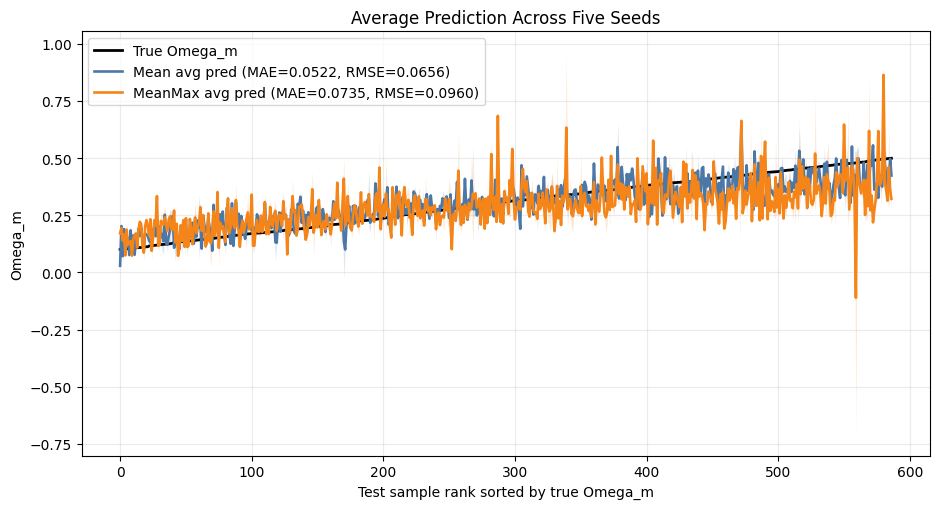

Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/average_prediction_across_5seeds_true_vs_predicted.png


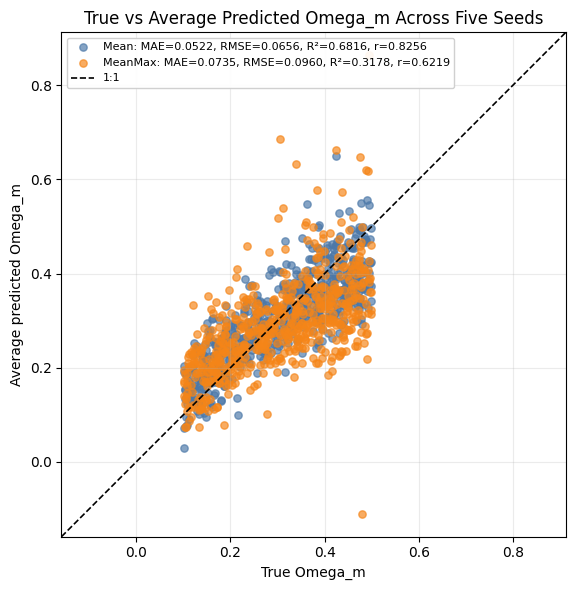

In [28]:
def load_seed_prediction_table(experiment_item: dict) -> pd.DataFrame | None:
    """Load one experiment's test predictions with universe, target, prediction, seed, and pooling fields."""
    prediction_path = Path(experiment_item["Experiment Path"]) / "predictions" / "test_predictions.csv"
    pred_df = load_prediction_csv(prediction_path)
    if pred_df is None:
        return None
    true_col, pred_col = infer_true_pred_columns(pred_df)
    if "universe_id" not in pred_df.columns:
        raise KeyError(f"Missing universe_id column in {prediction_path}")
    return pd.DataFrame({
        "Pooling": experiment_item["Pooling"],
        "Seed": experiment_item["Seed"],
        "Experiment": experiment_item["Experiment"],
        "universe_id": pred_df["universe_id"].astype(str),
        "true_omega_m": pred_df[true_col].astype(float),
        "pred_omega_m": pred_df[pred_col].astype(float),
    })


seed_prediction_frames = []
for item in EXPERIMENTS:
    loaded = load_seed_prediction_table(item)
    if loaded is not None:
        seed_prediction_frames.append(loaded)

all_seed_predictions = pd.concat(seed_prediction_frames, ignore_index=True) if seed_prediction_frames else pd.DataFrame()

true_consistency = (
    all_seed_predictions.groupby(["Pooling", "universe_id"])["true_omega_m"]
    .agg(true_min="min", true_max="max", n_true_values="nunique", n_rows="size")
    .reset_index()
)
true_consistency["true_range"] = true_consistency["true_max"] - true_consistency["true_min"]
true_matched_across_seeds = bool((true_consistency["true_range"] <= 1e-12).all())

seed_counts_by_pooling = (
    all_seed_predictions.groupby("Pooling")["Seed"]
    .nunique()
    .reindex(["Mean", "MeanMax"])
    .fillna(0)
    .astype(int)
)
all_five_seeds_found = bool((seed_counts_by_pooling == 5).all())

average_prediction_table = (
    all_seed_predictions.groupby(["Pooling", "universe_id"], as_index=False)
    .agg(
        true_omega_m=("true_omega_m", "first"),
        mean_pred_omega_m=("pred_omega_m", "mean"),
        std_pred_omega_m=("pred_omega_m", "std"),
        n_seeds=("Seed", "nunique"),
    )
    .sort_values(["Pooling", "universe_id"])
    .reset_index(drop=True)
)

save_csv(average_prediction_table, OUT_DIR / "average_prediction_across_seeds.csv")
display(average_prediction_table.head())
print("Seeds found by pooling:")
print(seed_counts_by_pooling)
print(f"All five seeds found for both pooling methods: {all_five_seeds_found}")
print(f"True Omega_m matched across seeds for each pooling/universe_id: {true_matched_across_seeds}")

if not true_matched_across_seeds:
    inconsistent_true = true_consistency[true_consistency["true_range"] > 1e-12]
    display(inconsistent_true)

mean_avg = average_prediction_table[average_prediction_table["Pooling"] == "Mean"].set_index("universe_id")
meanmax_avg = average_prediction_table[average_prediction_table["Pooling"] == "MeanMax"].set_index("universe_id")
common_universe_ids = mean_avg.index.intersection(meanmax_avg.index)

true_common_check = pd.DataFrame({
    "true_mean": mean_avg.loc[common_universe_ids, "true_omega_m"],
    "true_meanmax": meanmax_avg.loc[common_universe_ids, "true_omega_m"],
})
true_matched_between_pooling = bool(np.allclose(true_common_check["true_mean"], true_common_check["true_meanmax"], atol=1e-12, rtol=0.0))
print(f"Common universe_id count for Mean and MeanMax: {len(common_universe_ids)}")
print(f"True Omega_m matched between pooling methods for common universe_id set: {true_matched_between_pooling}")

ordered_universe_ids = true_common_check.assign(true_omega_m=true_common_check["true_mean"]).sort_values("true_omega_m").index
true_sorted = mean_avg.loc[ordered_universe_ids, "true_omega_m"].to_numpy(dtype=float)
mean_pred_sorted = mean_avg.loc[ordered_universe_ids, "mean_pred_omega_m"].to_numpy(dtype=float)
mean_pred_std_sorted = mean_avg.loc[ordered_universe_ids, "std_pred_omega_m"].fillna(0.0).to_numpy(dtype=float)
meanmax_pred_sorted = meanmax_avg.loc[ordered_universe_ids, "mean_pred_omega_m"].to_numpy(dtype=float)
meanmax_pred_std_sorted = meanmax_avg.loc[ordered_universe_ids, "std_pred_omega_m"].fillna(0.0).to_numpy(dtype=float)

average_prediction_metrics = {}
for pooling, pred_values in [("Mean", mean_pred_sorted), ("MeanMax", meanmax_pred_sorted)]:
    average_prediction_metrics[pooling] = {
        "MAE": compute_mae(true_sorted, pred_values),
        "RMSE": compute_rmse(true_sorted, pred_values),
        "R²": compute_r2(true_sorted, pred_values),
        "Pearson": compute_pearson(true_sorted, pred_values),
    }

x = np.arange(len(ordered_universe_ids))
fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.plot(x, true_sorted, color="black", linewidth=2.0, label="True Omega_m")
ax.plot(
    x,
    mean_pred_sorted,
    color="#4c78a8",
    linewidth=1.9,
    label=f"Mean avg pred (MAE={average_prediction_metrics['Mean']['MAE']:.4f}, RMSE={average_prediction_metrics['Mean']['RMSE']:.4f})",
)
ax.fill_between(x, mean_pred_sorted - mean_pred_std_sorted, mean_pred_sorted + mean_pred_std_sorted, color="#4c78a8", alpha=0.18, linewidth=0)
ax.plot(
    x,
    meanmax_pred_sorted,
    color="#f58518",
    linewidth=1.9,
    label=f"MeanMax avg pred (MAE={average_prediction_metrics['MeanMax']['MAE']:.4f}, RMSE={average_prediction_metrics['MeanMax']['RMSE']:.4f})",
)
ax.fill_between(x, meanmax_pred_sorted - meanmax_pred_std_sorted, meanmax_pred_sorted + meanmax_pred_std_sorted, color="#f58518", alpha=0.18, linewidth=0)
ax.set_title("Average Prediction Across Five Seeds")
ax.set_xlabel("Test sample rank sorted by true Omega_m")
ax.set_ylabel("Omega_m")
ax.grid(alpha=0.25)
ax.legend(loc="best")
fig.tight_layout()
save_current_figure(OUT_DIR / "average_prediction_across_5seeds_sorted_curve.png")
plt.show()

lo = float(min(true_sorted.min(), mean_pred_sorted.min(), meanmax_pred_sorted.min()))
hi = float(max(true_sorted.max(), mean_pred_sorted.max(), meanmax_pred_sorted.max()))
pad = (hi - lo) * 0.05 if hi > lo else 0.01
lo -= pad
hi += pad

fig, ax = plt.subplots(figsize=(6.2, 6.0))
ax.scatter(
    true_sorted,
    mean_pred_sorted,
    s=28,
    alpha=0.68,
    color="#4c78a8",
    label=(
        "Mean: "
        f"MAE={average_prediction_metrics['Mean']['MAE']:.4f}, "
        f"RMSE={average_prediction_metrics['Mean']['RMSE']:.4f}, "
        f"R²={average_prediction_metrics['Mean']['R²']:.4f}, "
        f"r={average_prediction_metrics['Mean']['Pearson']:.4f}"
    ),
)
ax.scatter(
    true_sorted,
    meanmax_pred_sorted,
    s=28,
    alpha=0.68,
    color="#f58518",
    label=(
        "MeanMax: "
        f"MAE={average_prediction_metrics['MeanMax']['MAE']:.4f}, "
        f"RMSE={average_prediction_metrics['MeanMax']['RMSE']:.4f}, "
        f"R²={average_prediction_metrics['MeanMax']['R²']:.4f}, "
        f"r={average_prediction_metrics['MeanMax']['Pearson']:.4f}"
    ),
)
ax.plot([lo, hi], [lo, hi], color="black", linestyle="--", linewidth=1.2, label="1:1")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal", adjustable="box")
ax.set_title("True vs Average Predicted Omega_m Across Five Seeds")
ax.set_xlabel("True Omega_m")
ax.set_ylabel("Average predicted Omega_m")
ax.grid(alpha=0.25)
ax.legend(loc="upper left", fontsize=8, framealpha=0.92)
fig.tight_layout()
save_current_figure(OUT_DIR / "average_prediction_across_5seeds_true_vs_predicted.png")
plt.show()


This figure shows the typical prediction behavior after averaging across the five matched seeds. If `MeanMax` remains flatter or farther from the true curve, it confirms that the worse result is not only due to one unlucky seed. If `Mean` follows the true curve better, the graph-pooling ablation does not support `mean_max` as an improvement over mean pooling.


## 14. Interpretation Checklist

The checklist is computed from the saved predictions and seed-level results. It is not manually hardcoded.


In [29]:
improved_seed_count = int(paired_seed_mae["Improved?"].sum())
meanmax_success = bool((meanmax_summary["Test MAE_mean"] < mean_summary["Test MAE_mean"]) and (improved_seed_count >= 3))

checklist = pd.DataFrame([
    {"Question": "Did mean_max improve mean MAE?", "Result": yes_no(meanmax_summary["Test MAE_mean"] < mean_summary["Test MAE_mean"]), "Mean": f"{mean_summary['Test MAE_mean']:.6f}", "MeanMax": f"{meanmax_summary['Test MAE_mean']:.6f}"},
    {"Question": "Did mean_max improve at least 3/5 seeds?", "Result": yes_no(improved_seed_count >= 3), "Mean": "baseline", "MeanMax": f"{improved_seed_count}/5 improved"},
    {"Question": "Did mean_max improve RMSE?", "Result": yes_no(meanmax_summary["Test RMSE_mean"] < mean_summary["Test RMSE_mean"]), "Mean": f"{mean_summary['Test RMSE_mean']:.6f}", "MeanMax": f"{meanmax_summary['Test RMSE_mean']:.6f}"},
    {"Question": "Did mean_max improve R²?", "Result": yes_no(meanmax_summary["Test R²_mean"] > mean_summary["Test R²_mean"]), "Mean": f"{mean_summary['Test R²_mean']:.6f}", "MeanMax": f"{meanmax_summary['Test R²_mean']:.6f}"},
    {"Question": "Did mean_max improve Pearson?", "Result": yes_no(meanmax_summary["Pearson_mean"] > mean_summary["Pearson_mean"]), "Mean": f"{mean_summary['Pearson_mean']:.6f}", "MeanMax": f"{meanmax_summary['Pearson_mean']:.6f}"},
    {"Question": "Did mean_max improve prediction spread?", "Result": yes_no(abs(1.0 - meanmax_summary["Prediction Std / Target Std_mean"]) < abs(1.0 - mean_summary["Prediction Std / Target Std_mean"])), "Mean": f"{mean_summary['Prediction Std / Target Std_mean']:.6f}", "MeanMax": f"{meanmax_summary['Prediction Std / Target Std_mean']:.6f}"},
    {"Question": "Did mean_max reduce repeated predictions?", "Result": yes_no(meanmax_summary["Repeat Fraction_mean"] < mean_summary["Repeat Fraction_mean"]), "Mean": f"{mean_summary['Repeat Fraction_mean']:.6f}", "MeanMax": f"{meanmax_summary['Repeat Fraction_mean']:.6f}"},
    {"Question": "Is graph pooling likely the main bottleneck?", "Result": "Less likely" if not meanmax_success else "Possible", "Mean": "linear + mean", "MeanMax": "linear + mean_max"},
])

save_csv(checklist, OUT_DIR / "interpretation_checklist.csv")
display(checklist)
save_table_png(checklist, OUT_DIR / "interpretation_checklist_table.png", title="Interpretation Checklist")


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/interpretation_checklist.csv


,Question,Result,Mean,MeanMax
0,Did mean_max improve mean MAE?,No,0.055843,0.080973
1,Did mean_max improve at least 3/5 seeds?,No,baseline,0/5 improved
2,Did mean_max improve RMSE?,No,0.071136,0.106170
3,Did mean_max improve R²?,No,0.627697,0.165548
4,Did mean_max improve Pearson?,No,0.814210,0.627348
5,Did mean_max improve prediction spread?,Yes,0.862457,0.863478
6,Did mean_max reduce repeated predictions?,No,0.004975,0.004975
7,Is graph pooling likely the main bottleneck?,Less likely,linear + mean,linear + mean_max


Saved: <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/interpretation_checklist_table.png


## 15. Final Conclusion

The final conclusion is generated from the computed comparison so that the notebook conclusion follows the actual saved results rather than a manually entered expectation.


In [30]:
if meanmax_success:
    conclusion = f"""
## Computed Conclusion

Mean+max graph pooling improved the controlled five-seed comparison by reducing mean Test MAE from `{mean_summary['Test MAE_mean']:.6f}` to `{meanmax_summary['Test MAE_mean']:.6f}` and improving `{improved_seed_count}/5` matched seeds. Under the pre-specified success rule, this supports the hypothesis that mean-only graph pooling was limiting the current linear-head EvolveGCN-H setup. The remaining diagnostics should still be interpreted alongside RMSE, R², Pearson correlation, residual structure, and prediction-spread behavior, because a lower MAE alone does not guarantee that the model has solved residual bias or prediction collapse.
"""
else:
    conclusion = f"""
## Computed Conclusion

This controlled ablation does not support the hypothesis that mean graph pooling is the dominant remaining bottleneck. Adding max-pooled information changed mean Test MAE from `{mean_summary['Test MAE_mean']:.6f}` for the linear-head mean-pooling baseline to `{meanmax_summary['Test MAE_mean']:.6f}` for mean+max pooling, with `{improved_seed_count}/5` matched seeds improving. Under the pre-specified success rule, mean+max pooling is therefore not successful in this comparison.

Adding max-pooled information worsened performance compared with the linear-head mean-pooling baseline. Therefore, the remaining limitation is more likely related to temporal aggregation, encoder representation, or the gap between learned graph representations and summary-feature baselines.
"""

display(Markdown(conclusion))



## Computed Conclusion

This controlled ablation does not support the hypothesis that mean graph pooling is the dominant remaining bottleneck. Adding max-pooled information changed mean Test MAE from `0.055843` for the linear-head mean-pooling baseline to `0.080973` for mean+max pooling, with `0/5` matched seeds improving. Under the pre-specified success rule, mean+max pooling is therefore not successful in this comparison.

Adding max-pooled information worsened performance compared with the linear-head mean-pooling baseline. Therefore, the remaining limitation is more likely related to temporal aggregation, encoder representation, or the gap between learned graph representations and summary-feature baselines.


## 16. Output Artifacts

The final cell lists all CSV and PNG files written by this notebook.


In [31]:
print("CSV files created:")
for path in SAVED_CSVS:
    print(f"- {path}")

print("\nPNG files created:")
for path in SAVED_PNGS:
    print(f"- {path}")

if warning_df.empty:
    print("\nWarnings: none")
else:
    print("\nWarnings:")
    display(warning_df)


CSV files created:
- <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/seed_level_results.csv
- <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/group_summary_numeric.csv
- <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/group_summary_mean_std.csv
- <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/paired_seed_mae_comparison.csv
- <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/collapse_diagnostics_seed_level.csv
- <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/average_prediction_across_seeds.csv
- <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/interpretation_checklist.csv

PNG files created:
- <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/seed_level_results_table.png
- <REPO_ROOT>/outputs/evolvegcn_750u_top1000_mean_vs_meanmax_pooling_results/group_summary_mean_std_table.pn